In [35]:
%load_ext cudf.pandas

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


In [36]:
import pickle

# Load the model back
with open('/kaggle/input/datasets/mudarc/my-dataset/df_1.kl', 'rb') as f:
    df = pickle.load(f)

In [37]:
df.head(10)

,id,name,date,day_name,hour,timezone,airlines,feedback,reason,reason_confidence,retweets,sentiment
0,570306133677760513,cairdin,2015-02-24,Tuesday,11,Eastern_Time,Virgin_America,What said.,Flight Booking Problems,0.00000,0,neutral
1,570301130888122368,jnardino,2015-02-24,Tuesday,11,Pacific_Time,Virgin_America,plus you've added commercials to the experienc...,Customer Service Issue,0.00000,0,positive
2,570301083672813571,yvonnalynn,2015-02-24,Tuesday,11,Central_Time,Virgin_America,I didn't today... Must mean I need to take ano...,Flight Attendant Complaints,0.00000,0,neutral
3,570301031407624196,jnardino,2015-02-24,Tuesday,11,Pacific_Time,Virgin_America,"it's really aggressive to blast obnoxious ""ent...",Bad Flight,0.70330,0,negative
4,570300817074462722,jnardino,2015-02-24,Tuesday,11,Pacific_Time,Virgin_America,and it's a really big bad thing about it,Can't Tell,1.00000,0,negative
5,570300767074181121,jnardino,2015-02-24,Tuesday,11,Pacific_Time,Virgin_America,seriously would pay $30 a flight for seats tha...,Can't Tell,0.68420,0,negative
6,570300616901320704,cjmcginnis,2015-02-24,Tuesday,11,Pacific_Time,Virgin_America,"yes, nearly every time I fly VX this “ear worm...",Customer Service Issue,0.00000,0,positive
7,570300248553349120,pilot,2015-02-24,Tuesday,11,Pacific_Time,Virgin_America,Really missed a prime opportunity for Men With...,Customer Service Issue,0.00000,0,neutral
8,570299953286942721,dhepburn,2015-02-24,Tuesday,11,Pacific_Time,Virgin_America,"Well, I didn't…but NOW I DO! :-D",Customer Service Issue,0.00000,0,positive
9,570295459631263746,YupitsTate,2015-02-24,Tuesday,10,Eastern_Time,Virgin_America,"it was amazing, and arrived an hour early. You...",Bad Flight,0.23895,0,positive


In [38]:
df = df.drop(columns=['id','name','date'])

In [39]:
df['reason'] = df['reason'].str.replace(" ", "_")

In [40]:
df.head(5)

,day_name,hour,timezone,airlines,feedback,reason,reason_confidence,retweets,sentiment
0,Tuesday,11,Eastern_Time,Virgin_America,What said.,Flight_Booking_Problems,0.0000,0,neutral
1,Tuesday,11,Pacific_Time,Virgin_America,plus you've added commercials to the experienc...,Customer_Service_Issue,0.0000,0,positive
2,Tuesday,11,Central_Time,Virgin_America,I didn't today... Must mean I need to take ano...,Flight_Attendant_Complaints,0.0000,0,neutral
3,Tuesday,11,Pacific_Time,Virgin_America,"it's really aggressive to blast obnoxious ""ent...",Bad_Flight,0.7033,0,negative
4,Tuesday,11,Pacific_Time,Virgin_America,and it's a really big bad thing about it,Can't_Tell,1.0000,0,negative


## **Using `MinMaxScaler` on hour, and `StandardScaler` on reason_confidence, and retweets**

In [41]:
data = df.copy()
data.sample(5)

,day_name,hour,timezone,airlines,feedback,reason,reason_confidence,retweets,sentiment
3256,Thursday,16,Atlantic_Time_(Canada),United,thanks for the reply. I have been in contact w...,Customer_Service_Issue,0.0000,0,positive
11703,Tuesday,13,Quito,US_Airways,It's the rude and arrogant gate personnel. Unc...,Customer_Service_Issue,0.6776,1,negative
9042,Tuesday,9,Eastern_Time,US_Airways,.I did but the more eyes I have looking for Pa...,Lost_Luggage,0.3542,2,negative
8096,Friday,7,Eastern_Time,Delta,sorry to report we are stuck on Tarmac.. Being...,Late_Flight,0.5386,0,negative
4080,Tuesday,15,Central_Time,United,Your MileagePlus signup page is broken.,Flight_Booking_Problems,0.6886,0,negative


In [42]:
data.select_dtypes(include='object').head()

,day_name,timezone,airlines,feedback,reason,sentiment
0,Tuesday,Eastern_Time,Virgin_America,What said.,Flight_Booking_Problems,neutral
1,Tuesday,Pacific_Time,Virgin_America,plus you've added commercials to the experienc...,Customer_Service_Issue,positive
2,Tuesday,Central_Time,Virgin_America,I didn't today... Must mean I need to take ano...,Flight_Attendant_Complaints,neutral
3,Tuesday,Pacific_Time,Virgin_America,"it's really aggressive to blast obnoxious ""ent...",Bad_Flight,negative
4,Tuesday,Pacific_Time,Virgin_America,and it's a really big bad thing about it,Can't_Tell,negative


In [43]:
data.dtypes[data.dtypes == 'object'].reset_index()

,index,0
0,day_name,object
1,timezone,object
2,airlines,object
3,feedback,object
4,reason,object
5,sentiment,object


In [44]:
data.select_dtypes(include='object').nunique()

day_name         7
timezone        78
airlines         6
feedback     14340
reason          10
sentiment        3
dtype: int64

## Making a function to use tokenization and lemmatization

In [45]:
!pip install cleantext

In [46]:
import nltk
from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords
stop_words = stopwords.words('english')

from nltk.stem import WordNetLemmatizer
lmt = WordNetLemmatizer()

from cleantext import clean

In [ ]:
def transform(txt):
    txt = clean(txt, lowercase=True, punct=True)
    txt = word_tokenize(txt)

    temp = [lmt.lemmatize(word, pos='v') for word in txt if word not in stop_words]

    temp2 = temp[:]
    temp2 = " ".join(temp2)

    return temp2

In [48]:
transform('Hello this the God King, playing and singing songs of liberation')

'hello god king play sing songs liberation'

In [49]:
data.select_dtypes(include='object').nunique()

day_name         7
timezone        78
airlines         6
feedback     14340
reason          10
sentiment        3
dtype: int64

In [50]:
data['day_name'] = data['day_name'].apply(transform)
data['timezone'] = data['timezone'].apply(transform)
data['airlines'] = data['airlines'].apply(transform)
data['feedback'] = data['feedback'].apply(transform)
data['reason'] = data['reason'].apply(transform)

In [51]:
data.sample(10)

,day_name,hour,timezone,airlines,feedback,reason,reason_confidence,retweets,sentiment
14091,sunday,17,easterntime,american,901 miami rio participate represent yourstoryhere,customerserviceissue,0.248965,1,neutral
3679,wednesday,15,easterntime,unite,possible redeem miles one part round trip itin...,customerserviceissue,0.000000,0,neutral
1503,sunday,19,pacifictime,unite,get explanation ua978 são paulo houston delay ...,lateflight,0.672700,0,negative
10439,saturday,17,easterntime,usairways,suck flt 2692 late flight 20 mins miss connect...,lateflight,1.000000,0,negative
3984,tuesday,19,quito,unite,golf bag didnt top cover staffers say couldnt ...,flightattendantcomplaints,0.351600,0,negative
8964,monday,23,pacifictime,delta,really get nerve 😡😡 nothappy,canttell,0.650300,0,negative
658,tuesday,5,centraltime,unite,someone please explain process happen property...,lateflight,0.000000,0,neutral
13276,monday,8,easterntime,american,2 agents domestic check mia wtf huge line many...,cancelledflight,0.697200,0,negative
3828,wednesday,9,centraltime,unite,ridic cant transfer credit 400 amp youre take ...,flightbookingproblems,0.672900,0,negative
10217,sunday,5,easterntime,usairways,point dont need sorry need revers agt pick cal...,customerserviceissue,1.000000,0,negative



## Using label encoder on sentiment

In [52]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data[['sentiment']] = le.fit_transform(data[['sentiment']]) 

In [53]:
le.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

In [54]:
data.head(5)

,day_name,hour,timezone,airlines,feedback,reason,reason_confidence,retweets,sentiment
0,tuesday,11,easterntime,virginamerica,say,flightbookingproblems,0.0000,0,1
1,tuesday,11,pacifictime,virginamerica,plus youve add commercials experience tacky,customerserviceissue,0.0000,0,2
2,tuesday,11,centraltime,virginamerica,didnt today must mean need take another trip,flightattendantcomplaints,0.0000,0,1
3,tuesday,11,pacifictime,virginamerica,really aggressive blast obnoxious entertainmen...,badflight,0.7033,0,0
4,tuesday,11,pacifictime,virginamerica,really big bad thing,canttell,1.0000,0,0


## Using vectorization to convert all the text into vectors

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

#### Using ColumnTransformer to add the needed columns to add into one single column

In [56]:
data['combined_labels'] = data[['day_name','timezone','airlines','reason']].astype(str).agg(' '.join, axis=1)
data.sample(6)

,day_name,hour,timezone,airlines,feedback,reason,reason_confidence,retweets,sentiment,combined_labels
8685,wednesday,4,easterntime,delta,say update dont work dont get pay jet blue mon...,cancelledflight,0.6545,0,0,wednesday easterntime delta cancelledflight
3817,wednesday,9,easterntime,unite,22 dont really care comfort care profitability...,canttell,0.6658,0,0,wednesday easterntime unite canttell
8034,friday,11,easterntime,delta,flt 1202 delay,lateflight,0.0000,0,1,friday easterntime delta lateflight
2032,sunday,3,easterntime,unite,know thank standard reply,lostluggage,0.3548,0,0,sunday easterntime unite lostluggage
7727,saturday,17,centraltime,delta,saw one useless tsa agents inspect shoe,canttell,0.6364,0,0,saturday centraltime delta canttell
5523,friday,16,centraltime,southwest,tell marry lamp give ticket vegas show please ...,customerserviceissue,0.0000,0,1,friday centraltime southwest customerserviceissue


In [57]:
processor = ColumnTransformer(
    transformers=[
        ('labels_tf', TfidfVectorizer(ngram_range=(2,2)), 'combined_labels'),
        ('sentence_tf', TfidfVectorizer(ngram_range=(2,2)), 'feedback'),
        ('minmax', MinMaxScaler(), ['hour']),
        ('standard', StandardScaler(), ['reason_confidence', 'retweets'])
    ],
    remainder='drop'            # will drop rest of the unnecessary columns
)


In [58]:
x = processor.fit_transform(data)
print(len(x.toarray()))
x.toarray()

14640


array([[ 0.        ,  0.        ,  0.        , ...,  0.47826087,
        -1.20868402, -0.11082799],
       [ 0.        ,  0.        ,  0.        , ...,  0.47826087,
        -1.20868402, -0.11082799],
       [ 0.        ,  0.        ,  0.        , ...,  0.47826087,
        -1.20868402, -0.11082799],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.47826087,
        -1.20868402, -0.11082799],
       [ 0.        ,  0.        ,  0.        , ...,  0.47826087,
         0.49054576, -0.11082799],
       [ 0.        ,  0.        ,  0.        , ...,  0.47826087,
        -1.20868402, -0.11082799]])

In [59]:
y = data['sentiment'].values
y

array([1, 2, 1, ..., 1, 0, 1])

# Training the model

In [60]:
# Convert features to float32
x = x.astype('float32')

# Convert labels to int32 (for classification) or float32 (for regression)
y = y.astype('int32')

In [61]:
from sklearn.model_selection import train_test_split as ttt

# 1. Standard dataset split
x_train, x_test, y_train, y_test = ttt(x, y, test_size=0.3, random_state=42)

# 2. Extract into clean NumPy arrays (stored on CPU RAM to support clean KFold indexing)
if hasattr(x_train, "toarray"):
    x_train = x_train.toarray()
    x_test = x_test.toarray()
else:
    x_train = np.array(x_train)
    x_test = np.array(x_test)

# Convert labels to matching NumPy format
y_train = np.array(y_train)
y_test = np.array(y_test)

print("Training array setup on CPU safely. Shape:", x_train.shape)

Training array setup on CPU safely. Shape: (10248, 81510)


# Using Optuna to find the best model 

In [62]:
import optuna
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split as ttt
from cuml.ensemble import RandomForestClassifier as cuRF
from sklearn.ensemble import ExtraTreesClassifier

x_tr, x_val, y_tr, y_val = ttt(x_train, y_train, test_size=0.2, random_state=42)

def model(trial):
    classifier_name = trial.suggest_categorical('classifier', ['RandomForestClassifier', 'ExtraTreesClassifier'])

    n_estimators = trial.suggest_int('n_estimators', 50, 150, step=50)
    max_features = trial.suggest_float('max_features', 0.001, 0.05)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    if classifier_name == 'RandomForestClassifier':
        max_depth = trial.suggest_int('max_depth', 5, 16)

        clf = cuRF(
            n_estimators=n_estimators,
            max_depth=max_depth,
            max_features=max_features,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
    else:
        max_depth = trial.suggest_int('max_depth', 5, 25)

        clf = ExtraTreesClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            max_features=max_features,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42,
            n_jobs=-1
        )

    clf.fit(x_tr, y_tr)
    preds = clf.predict(x_val)
    
    return accuracy_score(y_val, preds)

In [63]:
x_train.shape

(10248, 81510)

In [64]:
study = optuna.create_study(direction='maximize')
study.optimize(model, n_trials=6)

best_params = study.best_params
classifier_name = best_params.pop('classifier')

[I 2026-05-27 06:18:40,519] A new study created in memory with name: no-name-113fa733-abb7-437a-8cf5-07f692f269d1
[I 2026-05-27 06:18:54,766] Trial 0 finished with value: 0.6209756097560976 and parameters: {'classifier': 'ExtraTreesClassifier', 'n_estimators': 100, 'max_features': 0.00790079284094058, 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_depth': 5}. Best is trial 0 with value: 0.6209756097560976.
[I 2026-05-27 06:19:03,839] Trial 1 finished with value: 0.6307317073170732 and parameters: {'classifier': 'RandomForestClassifier', 'n_estimators': 50, 'max_features': 0.017969215190745923, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_depth': 11}. Best is trial 1 with value: 0.6307317073170732.
[I 2026-05-27 06:21:35,063] Trial 2 finished with value: 0.6326829268292683 and parameters: {'classifier': 'ExtraTreesClassifier', 'n_estimators': 150, 'max_features': 0.020833217682580688, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_depth': 16}. Best is trial 2 with valu

In [65]:
if classifier_name == 'RandomForestClassifier':
    final_model = cuRF(**best_params, random_state=42)
elif classifier_name == 'ExtraTreesClassifier':
    final_model = ExtraTreesClassifier(**best_params, random_state=42, n_jobs=-1)

final_model.fit(x_train, y_train)
final_preds = final_model.predict(x_test)
final_accuracy = accuracy_score(y_test, final_preds)

In [66]:
print("Best Parameters:", study.best_params)
print()
print("Final Test Accuracy:", final_accuracy)

Best Parameters: {'classifier': 'ExtraTreesClassifier', 'n_estimators': 150, 'max_features': 0.020833217682580688, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_depth': 16}

Final Test Accuracy: 0.6518670309653917


In [67]:
from sklearn.metrics import recall_score, precision_score, confusion_matrix

In [70]:
print(f"PRECISION SCORE : {precision_score(y_test, final_preds, average='weighted')}")
print()
print(f"RECALL SCORE    : {recall_score(y_test, final_preds, average='weighted')}")
print()
print(f"CONFUSION MATRIX : \n{confusion_matrix(final_preds, y_test)}")

PRECISION SCORE : 0.751359471689744

RECALL SCORE    : 0.6518670309653917

CONFUSION MATRIX : 
[[2809  831  691]
 [   5   53    2]
 [   0    0    1]]


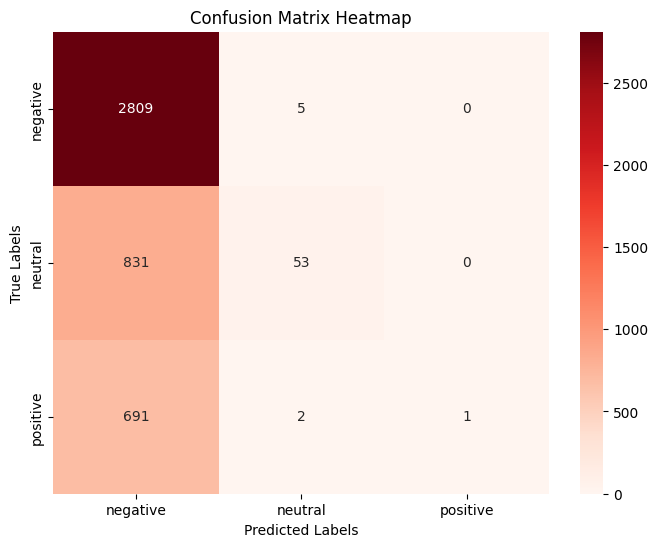

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=le.classes_, 
            yticklabels=le.classes_)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()